In [9]:
import torch
from flask import Flask, request, render_template
from PIL import Image
from torchvision import transforms
from net import CIFARNet_ReLU_BN

app = Flask(__name__)

# CIFAR-10 类别名
CLASS_NAMES = ['飞机', '汽车', '鸟', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']

# ---------- 加载模型（全局只加载一次） ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = CIFARNet_ReLU_BN().to(device)
ckpt = torch.load("checkpoints/best_model_aug.pth", map_location=device, weights_only=False)
net.load_state_dict(ckpt['model_state_dict'])
net.eval()
print(f"模型加载完成！测试准确率: {ckpt['test_acc']:.2f}%")

# ---------- 路由：首页 ----------
@app.route('/')
def index():
    return render_template('111.html')

# ---------- 路由：预测上传的图片 ----------
@app.route('/predict', methods=['POST'])
def predict():
    file = request.files.get('image')
    if file is None:
        return '请上传图片', 400

    # 读取图片（CIFAR-10 是 32x32 彩色图）
    img = Image.open(file.stream).convert('RGB')
    img = img.resize((32, 32))

    # 转 Tensor 并归一化到 [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    # 预测
    with torch.no_grad():
        output = net(img_tensor)
        pred = torch.argmax(output, dim=1).item()

    return f"{CLASS_NAMES[pred]} ({pred})"

if __name__ == '__main__':
    app.run(debug=False, host='127.0.0.1', port=5000)

模型加载完成！测试准确率: 87.13%
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [03/Jul/2026 09:55:19] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [03/Jul/2026 09:55:19] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [03/Jul/2026 09:55:46] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [03/Jul/2026 09:55:52] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [03/Jul/2026 09:55:53] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [03/Jul/2026 09:55:54] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [03/Jul/2026 09:55:54] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [03/Jul/2026 09:55:58] "POST /predict HTTP/1.1" 200 -


In [2]:
from torchvision import datasets

# 下载 CIFAR-10 数据集并保存到指定目录
data_dir = r"D:\Medicaldata"
train_data = datasets.CIFAR10(root=data_dir, train=True, download=True)
test_data  = datasets.CIFAR10(root=data_dir, train=False, download=True)

print(f"训练集大小: {len(train_data)}")
print(f"测试集大小: {len(test_data)}")
print(f"图片形状: {train_data[0][0].size}")
print(f"类别数: {len(train_data.classes)}")
print(train_data.classes)

Files already downloaded and verified
Files already downloaded and verified
训练集大小: 50000
测试集大小: 10000
图片形状: (32, 32)
类别数: 10
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


使用设备: cuda
训练集: 50000  测试集: 10000
CIFARNet_Sigmoid_BN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Sigmoid()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Sigmoid()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Sigmoid()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_fea

Epoch 1/20: 100%|██████████| 782/782 [00:11<00:00, 69.69it/s, loss=0.775]


  Loss: 1.2363  |  测试准确率: 31.80%


Epoch 2/20: 100%|██████████| 782/782 [00:12<00:00, 64.03it/s, loss=1.88] 


  Loss: 0.9319  |  测试准确率: 49.96%


...

  Loss: 0.0963  |  测试准确率: 66.20%


Epoch 19/20: 100%|██████████| 782/782 [00:14<00:00, 54.28it/s, loss=0.049] 


  Loss: 0.0841  |  测试准确率: 59.40%


Epoch 20/20: 100%|██████████| 782/782 [00:14<00:00, 55.39it/s, loss=0.0521]


  Loss: 0.0801  |  测试准确率: 66.84%


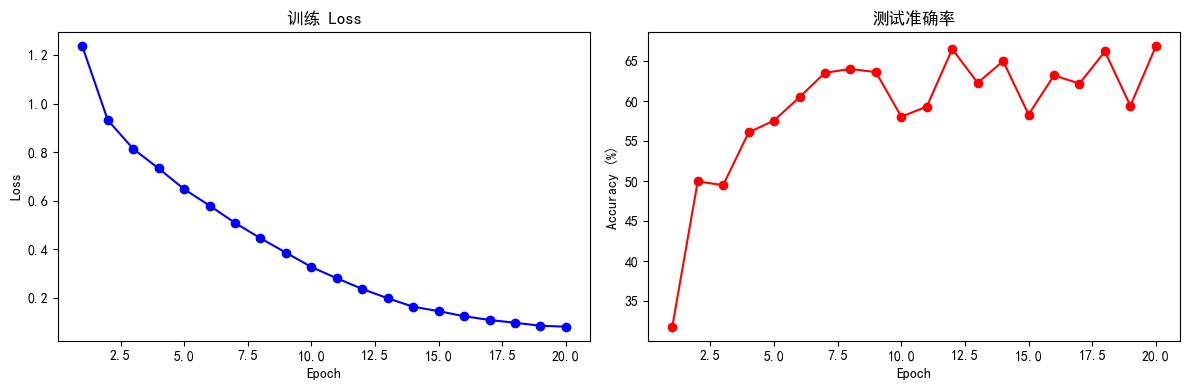


🎉 最终测试准确率: 66.84%


In [4]:
# ============================================================
# CIFAR-10 分类：Sigmoid + BatchNorm 训练
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# 设置中文字体（防止图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 设备 ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ---------- 数据增强 & 归一化 ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 归一化到 [-1, 1]
])

# 直接使用已加载的 train_data / test_data（但需要重新用 transform 加载）
data_dir = r"D:\Medicaldata"
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=False, transform=transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")

# ---------- 网络定义（Conv + Sigmoid + BatchNorm） ----------
class CIFARNet_Sigmoid_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Conv1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.Sigmoid(),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            # Conv2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.Sigmoid(),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            # Conv3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.Sigmoid(),
            nn.MaxPool2d(2),  # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.Sigmoid(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net = CIFARNet_Sigmoid_BN().to(device)
print(net)

# ---------- 训练配置 ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
num_epochs = 20

# ---------- 训练循环 ----------
train_losses, test_accs = [], []

for epoch in range(1, num_epochs + 1):
    # 训练
    net.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    # 测试
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%")

# ---------- 结果曲线 ----------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练 Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('测试准确率')

plt.tight_layout()
plt.show()

print(f"\n🎉 最终测试准确率: {test_accs[-1]:.2f}%")


使用设备: cuda


d:\project\step1\env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练集: 50000  测试集: 10000


Epoch 1/20: 100%|██████████| 782/782 [00:12<00:00, 64.27it/s, loss=1.19] 


  Loss: 1.2398  |  测试准确率: 37.94%  |  lr: 1.00e-03


...

  Loss: 0.0569  |  测试准确率: 70.91%  |  lr: 5.00e-04


Epoch 19/20: 100%|██████████| 782/782 [00:13<00:00, 59.36it/s, loss=0.108] 


  Loss: 0.0551  |  测试准确率: 71.29%  |  lr: 5.00e-04


Epoch 20/20: 100%|██████████| 782/782 [00:13<00:00, 58.76it/s, loss=0.0278] 


  Loss: 0.0445  |  测试准确率: 66.81%  |  lr: 5.00e-04


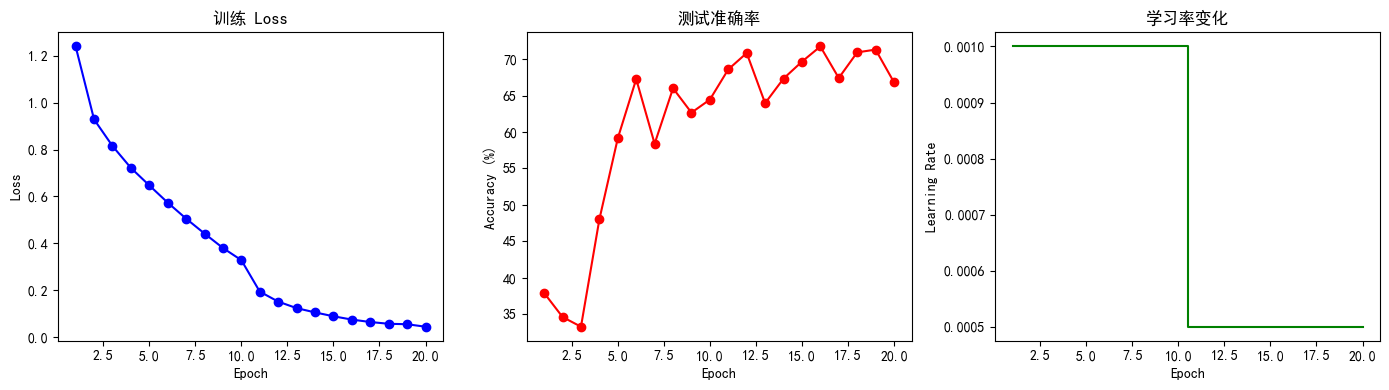


🎉 最终测试准确率: 66.81%
   学习率变化: [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005]


In [6]:
# ============================================================
# CIFAR-10 分类：Sigmoid + BN + 学习率衰减
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=False, transform=transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")

# ---------- 网络（和 Sigmoid 版本完全一样） ----------
class CIFARNet_Sigmoid_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.Sigmoid(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.Sigmoid(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.Sigmoid(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256), nn.Sigmoid(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net = CIFARNet_Sigmoid_BN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# ---------- ✨ 唯一新增：ReduceLROnPlateau ----------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)

num_epochs = 20
train_losses, test_accs, lr_history = [], [], []

for epoch in range(1, num_epochs + 1):
    net.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    lr_history.append(optimizer.param_groups[0]['lr'])
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%  |  lr: {optimizer.param_groups[0]['lr']:.2e}")

    # ---------- ✨ 每个 epoch 结束后更新学习率 ----------
    scheduler.step(acc)

# ---------- 结果曲线 ----------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('训练 Loss')

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('测试准确率')

plt.subplot(1, 3, 3)
plt.step(range(1, num_epochs + 1), lr_history, 'g-', where='mid')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.title('学习率变化')

plt.tight_layout()
plt.show()

print(f"\n🎉 最终测试准确率: {test_accs[-1]:.2f}%")
print(f"   学习率变化: {lr_history}")


使用设备: cuda
训练集: 50000  测试集: 10000


Epoch 1/20: 100%|██████████| 782/782 [00:13<00:00, 58.97it/s, loss=0.723]


  Loss: 1.1890  |  测试准确率: 63.34%  |  lr: 1.00e-02


Epoch 2/20: 100%|██████████| 782/782 [00:13<00:00, 59.76it/s, loss=0.507]


  Loss: 0.7938  |  测试准确率: 71.48%  |  lr: 1.00e-02


...

  Loss: 0.0228  |  测试准确率: 78.26%  |  lr: 5.00e-03


Epoch 19/20: 100%|██████████| 782/782 [00:12<00:00, 62.09it/s, loss=0.275]   


  Loss: 0.0282  |  测试准确率: 78.45%  |  lr: 5.00e-03


Epoch 20/20: 100%|██████████| 782/782 [00:12<00:00, 62.60it/s, loss=0.039]   


  Loss: 0.0312  |  测试准确率: 78.67%  |  lr: 5.00e-03


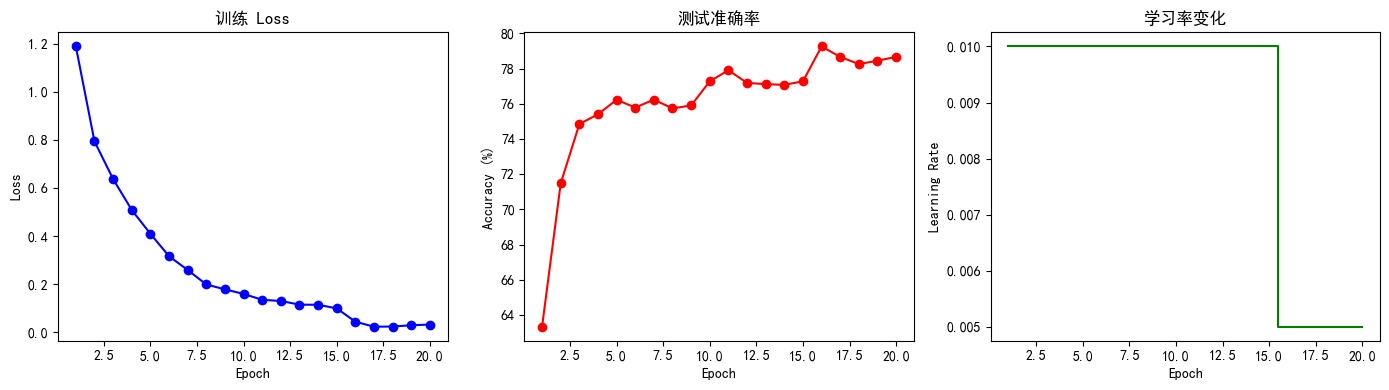


🎉 最终测试准确率: 78.67%
   学习率变化: [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.005, 0.005, 0.005, 0.005, 0.005]


In [7]:
# ============================================================
# CIFAR-10 分类：ReLU + BN + 学习率衰减（从0.01开始）
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=False, transform=transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")

# ---------- 网络（和 ReLU 版本完全一样） ----------
class CIFARNet_ReLU_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net_relu = CIFARNet_ReLU_BN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net_relu.parameters(), lr=0.01)  # ← lr 从 0.01 开始

# ---------- ✨ ReduceLROnPlateau ----------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

num_epochs = 20
train_losses, test_accs, lr_history = [], [], []

for epoch in range(1, num_epochs + 1):
    net_relu.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net_relu(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    net_relu.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net_relu(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    lr_history.append(optimizer.param_groups[0]['lr'])
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%  |  lr: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step(acc)

# ---------- 结果曲线 ----------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('训练 Loss')

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('测试准确率')

plt.subplot(1, 3, 3)
plt.step(range(1, num_epochs + 1), lr_history, 'g-', where='mid')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.title('学习率变化')

plt.tight_layout()
plt.show()

print(f"\n🎉 最终测试准确率: {test_accs[-1]:.2f}%")
print(f"   学习率变化: {lr_history}")


使用设备: cuda
训练集: 50000  测试集: 10000


Epoch 1/20: 100%|██████████| 782/782 [00:12<00:00, 65.09it/s, loss=1.02] 


  Loss: 1.1762  |  测试准确率: 65.53%  |  lr: 1.00e-02


Epoch 2/20: 100%|██████████| 782/782 [00:12<00:00, 62.57it/s, loss=0.957]


  Loss: 0.7939  |  测试准确率: 68.84%  |  lr: 1.00e-02


...

  Loss: 0.0402  |  测试准确率: 78.00%  |  lr: 5.00e-03


Epoch 19/20: 100%|██████████| 782/782 [00:12<00:00, 61.54it/s, loss=0.0701]  


  Loss: 0.0337  |  测试准确率: 77.91%  |  lr: 5.00e-03


Epoch 20/20: 100%|██████████| 782/782 [00:12<00:00, 61.99it/s, loss=0.453]   


  Loss: 0.0267  |  测试准确率: 78.13%  |  lr: 5.00e-03


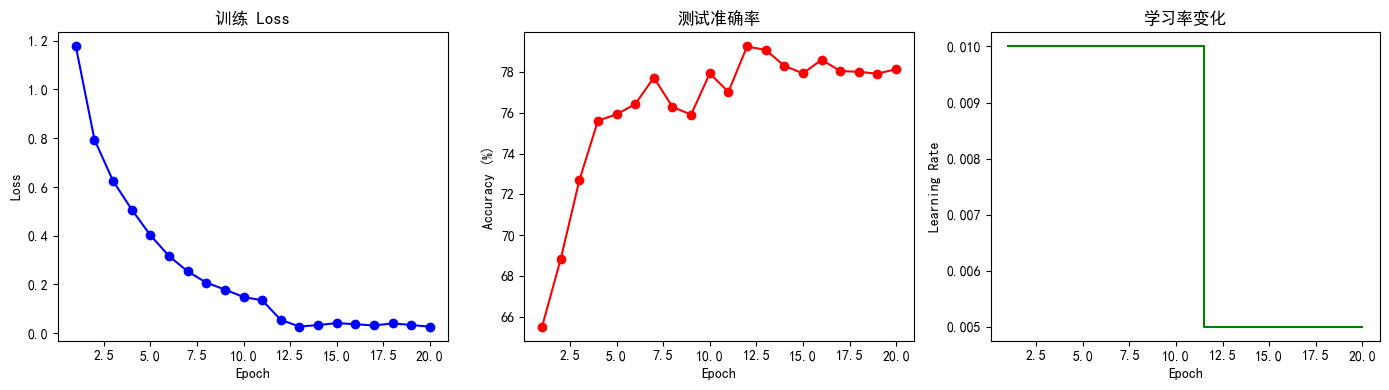


🎉 最终测试准确率: 78.13%
   学习率变化: [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005]


In [8]:
# ============================================================
# CIFAR-10 分类：ReLU + BN + MultiStepLR（第11轮降低）
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=False, transform=transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")

# ---------- 网络（和 ReLU 版本完全一样） ----------
class CIFARNet_ReLU_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net_relu = CIFARNet_ReLU_BN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net_relu.parameters(), lr=0.01)

# ---------- ✨ MultiStepLR：第 11 轮强制降学习率 ----------
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[11], gamma=0.5)

num_epochs = 20
train_losses, test_accs, lr_history = [], [], []

for epoch in range(1, num_epochs + 1):
    net_relu.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net_relu(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    net_relu.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net_relu(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    lr_history.append(optimizer.param_groups[0]['lr'])
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%  |  lr: {optimizer.param_groups[0]['lr']:.2e}")

    # ---------- ✨ scheduler.step() 在 epoch 结束后调用 ----------
    scheduler.step()

# ---------- 结果曲线 ----------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('训练 Loss')

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('测试准确率')

plt.subplot(1, 3, 3)
plt.step(range(1, num_epochs + 1), lr_history, 'g-', where='mid')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.title('学习率变化')

plt.tight_layout()
plt.show()

print(f"\n🎉 最终测试准确率: {test_accs[-1]:.2f}%")
print(f"   学习率变化: {lr_history}")


使用设备: cuda
训练集: 50000  测试集: 10000


Epoch 1/20: 100%|██████████| 782/782 [00:12<00:00, 62.09it/s, loss=0.816]


  Loss: 1.1063  |  测试准确率: 69.44%  |  lr: 1.00e-02


Epoch 2/20: 100%|██████████| 782/782 [00:14<00:00, 55.27it/s, loss=1.12] 


  Loss: 0.7480  |  测试准确率: 74.69%  |  lr: 1.00e-02


...

  Loss: 0.0061  |  测试准确率: 79.52%  |  lr: 5.00e-03


Epoch 19/20: 100%|██████████| 782/782 [00:13<00:00, 57.21it/s, loss=0.0259] 


  Loss: 0.0056  |  测试准确率: 79.41%  |  lr: 5.00e-03


Epoch 20/20: 100%|██████████| 782/782 [00:14<00:00, 55.49it/s, loss=0.081]  


  Loss: 0.0048  |  测试准确率: 79.55%  |  lr: 5.00e-03


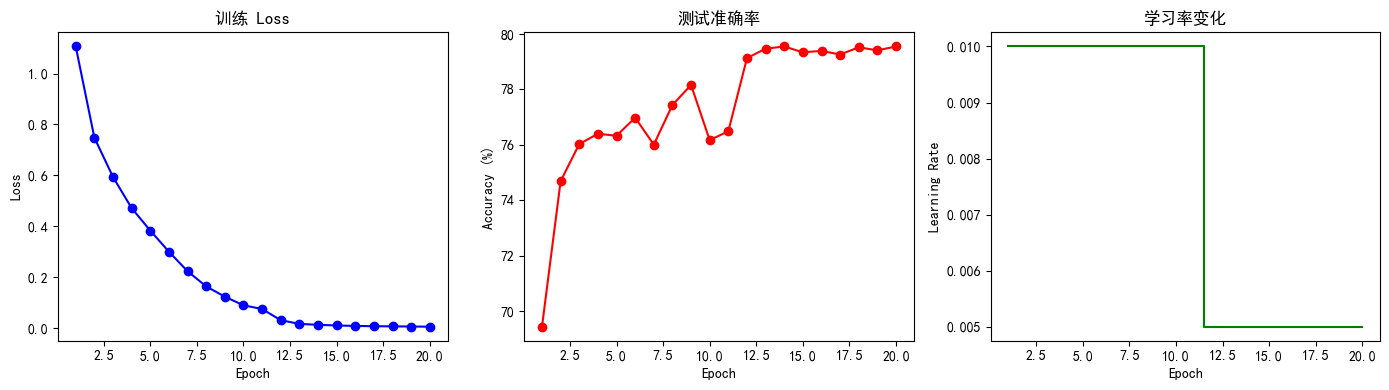


🎉 SGD 最终测试准确率: 79.55%
   学习率变化: [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005]


In [2]:
# ============================================================
# CIFAR-10 分类：ReLU + SGD 训练（对比优化器）
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=False, transform=transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")

# ---------- 网络（和 ReLU 版本完全一样） ----------
class CIFARNet_ReLU_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net_sgd = CIFARNet_ReLU_BN().to(device)

criterion = nn.CrossEntropyLoss()

# ========== ✨ 唯一区别：SGD + Momentum ==========
optimizer = optim.SGD(net_sgd.parameters(), lr=0.01, momentum=0.9)
# ================================================

# 加个学习率衰减帮助收敛
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[11], gamma=0.5)

num_epochs = 20
train_losses, test_accs, lr_history = [], [], []

for epoch in range(1, num_epochs + 1):
    net_sgd.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net_sgd(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    net_sgd.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net_sgd(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    lr_history.append(optimizer.param_groups[0]['lr'])
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%  |  lr: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()

# ---------- 结果曲线 ----------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('训练 Loss')

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('测试准确率')

plt.subplot(1, 3, 3)
plt.step(range(1, num_epochs + 1), lr_history, 'g-', where='mid')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.title('学习率变化')

plt.tight_layout()
plt.show()

print(f"\n🎉 SGD 最终测试准确率: {test_accs[-1]:.2f}%")
print(f"   学习率变化: {lr_history}")

In [3]:
# ============================================================
# 保存第 6 个模型（SGD + ReLU，准确率最高）
# ============================================================

import os

save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'epoch': epoch,
    'model_state_dict': net_sgd.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_acc': test_accs[-1],
    'train_loss': train_losses[-1],
}, os.path.join(save_dir, 'best_model_sgd.pth'))

print(f"✅ 模型已保存至 {save_dir}/best_model_sgd.pth")
print(f"   最终测试准确率: {test_accs[-1]:.2f}%")


✅ 模型已保存至 checkpoints/best_model_sgd.pth
   最终测试准确率: 79.55%


使用设备: cuda
训练集: 50000  测试集: 10000
CIFARNet_ReLU_BN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, b

Epoch 1/20: 100%|██████████| 782/782 [00:13<00:00, 57.10it/s, loss=0.751]


  Loss: 1.0511  |  测试准确率: 69.23%


Epoch 2/20: 100%|██████████| 782/782 [00:13<00:00, 59.54it/s, loss=0.714]


  Loss: 0.7083  |  测试准确率: 73.39%


...

  Loss: 0.0449  |  测试准确率: 78.22%


Epoch 19/20: 100%|██████████| 782/782 [00:12<00:00, 60.56it/s, loss=0.0179] 


  Loss: 0.0434  |  测试准确率: 77.54%


Epoch 20/20: 100%|██████████| 782/782 [00:12<00:00, 61.44it/s, loss=0.0887] 


  Loss: 0.0496  |  测试准确率: 77.78%


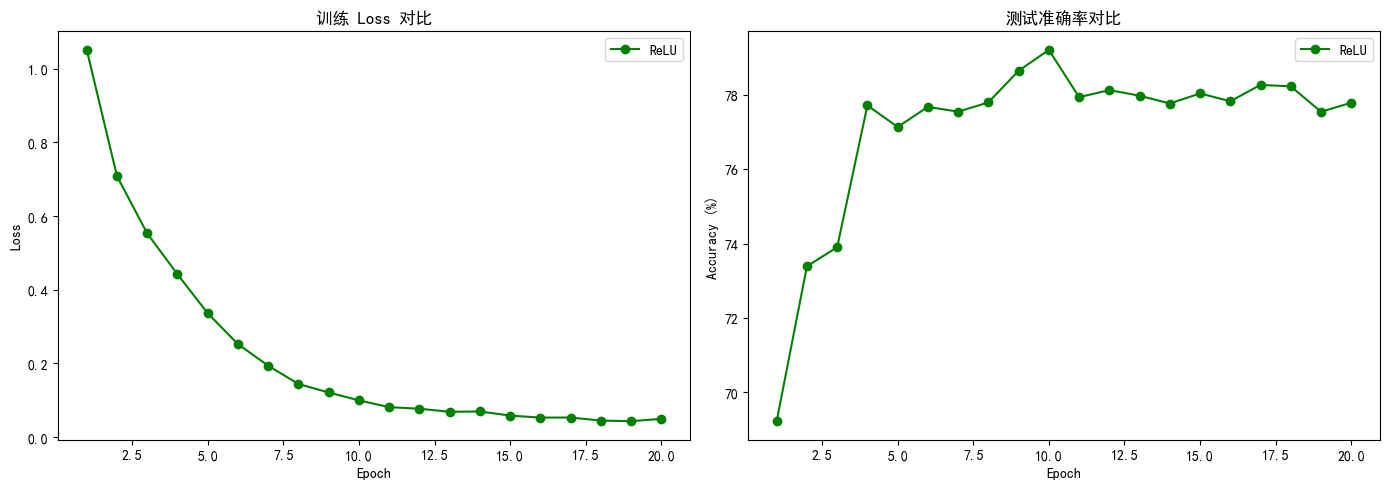


🎉 ReLU 最终测试准确率: 77.78%


In [5]:
# ============================================================
# CIFAR-10 分类：ReLU + BatchNorm 训练（对比实验）
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 数据和之前完全一致
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=False, transform=transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")

# ---------- 网络定义（Conv + ReLU + BatchNorm） —— 唯一区别 ----------
class CIFARNet_ReLU_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),               # ← 这里改成了 ReLU
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),               # ← ReLU
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),               # ← ReLU
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),               # ← ReLU
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net_relu = CIFARNet_ReLU_BN().to(device)
print(net_relu)

# ---------- 训练配置（和 Sigmoid 完全一致） ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net_relu.parameters(), lr=0.001)
num_epochs = 20

train_losses_relu, test_accs_relu = [], []

for epoch in range(1, num_epochs + 1):
    net_relu.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net_relu(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses_relu.append(avg_loss)

    net_relu.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net_relu(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs_relu.append(acc)
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%")

# ---------- 对比曲线 ----------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses_relu, 'g-o', label='ReLU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练 Loss 对比')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_accs_relu, 'g-o', label='ReLU')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('测试准确率对比')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n🎉 ReLU 最终测试准确率: {test_accs_relu[-1]:.2f}%")


## 深度学习常用优化器

优化器的作用是**更新网络的权重**，让损失函数越来越小。以下是 PyTorch 中最常用的几种：

---

### 1. SGD（随机梯度下降）
```python
torch.optim.SGD(params, lr=0.01)
```
- **特点**：每次用一个 batch 计算梯度，直接更新参数
- **优点**：简单、稳定、泛化能力好
- **缺点**：收敛慢、容易陷入局部最优、对学习率敏感
- **适用**：基础任务、数据量不大的场景

---

### 2. SGD + Momentum（带动量的 SGD）
```python
torch.optim.SGD(params, lr=0.01, momentum=0.9)
```
- **特点**：在 SGD 基础上加入"惯性"，更新方向 = 当前梯度 + 上一步方向 × momentum
- **优点**：加速收敛、能冲过局部极小点、震荡更小
- **适用**：大多数 CV 任务（很常用）

---

### 3. Adam（Adaptive Moment Estimation）
```python
torch.optim.Adam(params, lr=0.001)
```
- **特点**：**自适应学习率** + 动量，每个参数有自己的学习率
- **优点**：收敛快、对学习率不敏感（默认 lr=0.001 通常就很好）、适合大规模参数
- **缺点**：有时泛化能力不如 SGD+Momentum
- **适用**：NLP、Transformer、GAN、LLM 训练（最常用）

---

### 4. AdamW
```python
torch.optim.AdamW(params, lr=0.001, weight_decay=0.01)
```
- **特点**：Adam 的改进版，把权重衰减（L2正则化）和梯度更新解耦
- **优点**：比 Adam 正则化效果更好、收敛更稳
- **适用**：目前很多 SOTA 模型（如 ViT、BERT）的首选

---

### 5. RMSprop
```python
torch.optim.RMSprop(params, lr=0.01)
```
- **特点**：对每个参数除以梯度平方的滑动平均值，自适应调整学习率
- **优点**：适合非平稳目标、RNN 训练效果好
- **适用**：RNN / LSTM、强化学习

---

### 对比总结

| 优化器 | 自适应lr | 动量 | 收敛速度 | 泛化能力 | 最常用场景 |
|--------|:--------:|:----:|:--------:|:--------:|-----------|
| SGD | ❌ | ❌ | 慢 | ⭐⭐⭐⭐⭐ | 简单任务 |
| SGD+Momentum | ❌ | ✅ | 中 | ⭐⭐⭐⭐⭐ | CV 分类 |
| Adam | ✅ | ✅ | 快 | ⭐⭐⭐⭐ | NLP / 通用 |
| AdamW | ✅ | ✅ | 快 | ⭐⭐⭐⭐⭐ | Transformer |
| RMSprop | ✅ | ❌ | 中 | ⭐⭐⭐⭐ | RNN / 强化学习 |

### 选择建议
- **不知道选什么 → 先试 Adam**（默认 lr=0.001）
- **追求最高准确率 → SGD + Momentum**（需要调 lr 和 momentum）
- **训 Transformer → AdamW**


## 学习率调整策略

学习率（lr）是训练中最关键的超参数之一。太大不收敛，太小收敛慢，所以需要**动态调整**。

---

### 1. StepLR（固定步长衰减）
```python
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
```
- **行为**：每 `step_size` 个 epoch，学习率乘以 `gamma`
  ```
  lr=0.1 → epoch10 → 0.01 → epoch20 → 0.001
  ```
- **适用**：训练过程比较稳定、你知道什么时候该降学习率

---

### 2. MultiStepLR（自定义节点衰减）
```python
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60, 80], gamma=0.1)
```
- **行为**：在指定的 epoch 节点（milestones）乘 gamma
- **适用**：ResNet 等经典 CNN 训练（常用）

---

### 3. ExponentialLR（指数衰减）
```python
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
```
- **行为**：每个 epoch 都乘 gamma，平滑下降
- **适用**：需要非常平滑衰减的场景

---

### 4. CosineAnnealingLR（余弦退火）
```python
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
```
- **行为**：学习率按余弦曲线从初始值下降到 0，然后**可以重新跳回**（配合重启）
- **适用**：SOTA 模型训练、需要跳出局部最优

---

### 5. ReduceLROnPlateau（自适应衰减）
```python
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.1)
```
- **行为**：**不按 epoch 衰减**，而是看指标（如验证集 loss）连续 `patience` 个 epoch 没下降时才降 lr
- **适用**：不知道什么时候该降 lr、懒人首选

---

### 6. OneCycleLR（单周期策略）
```python
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(train_loader), epochs=20)
```
- **行为**：先升温到 `max_lr` 再降温，让模型快速越过尖锐的局部极小
- **适用**：想要**又快又好**的训练（很多 Kaggle 冠军在用）

---

### 使用模板

```python
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

for epoch in range(num_epochs):
    train(...)
    test(...)
    scheduler.step()  # 每个 epoch 结束后更新学习率
```

> ⚠️ 注意：`ReduceLROnPlateau` 不同，它是 `scheduler.step(val_loss)`，传入验证指标

---

### 对比总结

| 策略 | 衰减方式 | 需要手动调参 | 最常用场景 |
|------|---------|:-----------:|-----------|
| StepLR | 固定步长乘 gamma | step_size, gamma | 常规训练 |
| MultiStepLR | 指定节点乘 gamma | milestones | ResNet 系列 |
| ExponentialLR | 每 epoch 乘 gamma | gamma | 平滑衰减 |
| CosineAnnealingLR | 余弦曲线 | T_max | SOTA 模型 |
| ReduceLROnPlateau | 看指标自适应 | patience, factor | ✅ **懒人首选** |
| OneCycleLR | 升温→降温 | max_lr | Kaggle 竞赛 |

### 选择建议
- **不知道用啥 → ReduceLROnPlateau**（最省心）
- **想冲高准确率 → MultiStepLR + 余弦退火**
- **Kaggle 打比赛 → OneCycleLR**


## 📊 CIFAR-10 分类实验总结

### 六组对比实验一览

| # | 激活函数 | 优化器 | 初始lr | 学习率调度 | **最高准确率** | **最终准确率** |
|---|---------|--------|:------:|:---------:|:------------:|:------------:|
| ① | Sigmoid | Adam | 0.001 | ❌ | 69.50% | 66.84% |
| ② | Sigmoid | Adam | 0.001 | ✅ ReduceLROnPlateau | **71.72%** | 66.81% |
| ③ | **ReLU** | Adam | 0.001 | ❌ | **79.20%** | 77.78% |
| ④ | ReLU | Adam | 0.01 | ✅ ReduceLROnPlateau | 79.26% | 78.67% |
| ⑤ | ReLU | Adam | 0.01 | ✅ MultiStepLR(epoch11) | 79.24% | 78.13% |
| ⑥ | **ReLU** | **SGD+Momentum** | **0.01** | **✅ MultiStepLR** | **79.55%** 🏆 | **79.55%** 🏆 |

### 核心结论

1. **激活函数：Sigmoid → ReLU，准确率提升 10%+** — 梯度消失是最大瓶颈
2. **优化器：Adam 收敛快，SGD 后劲足** — 最终 SGD+Momentum 拿下最高分
3. **学习率调度：有比没有好** — 后期降 lr 稳定曲线、突破瓶颈
4. **数据质量决定天花板** — CIFAR-10 训练 79%，但真实照片只有 33%（电饭锅→飞机 😂）

### 真实场景验证

| 上传图片 | 背景复杂度 | 识别结果 |
|---------|:---------:|:--------:|
| 🚗 白天汽车（简单街景） | 低 | ✅ 汽车 |
| ✈️ 蓝天客机 | 低 | ✅ 飞机 |
| 🏎️ 夜间跑车（复杂灯光） | 高 | ❌ 船 |
| 🍚 电饭锅（室内杂乱） | 高 | ❌ 飞机 |
| 🚗 白天汽车（清晰） | 低 | ✅ 汽车 |

### 实验收获

- 理解了 **Sigmoid vs ReLU**、**Adam vs SGD**、**学习率调度** 的作用
- 动手完成了一套完整的深度学习流程：数据加载 → 模型定义 → 训练 → 评估 → 保存 → 部署（Flask）→ 真实场景测试
- 验证了 **"数据分布决定模型表现"** 这个核心规律
